# Feature Engineering v3

Feature:

Candle Range Compression

Objective:

Measure candle-size contraction relative to historical baseline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
path = r"C:\Users\LENOVO\AlgoTrading_Research\statistical-range-detection\data\processed\eurusd_h1_features_v2.csv"

df = pd.read_csv(path, parse_dates=["date"], index_col="date")
df.head()

,open,high,low,close,tick_volume,spread,returns,log_returns,tr,atr_14,atr_mean_16,atr_mean_48,atr_rel_16,atr_rel_48,std_16,std_48,std_rel_16,std_rel_48
date,,,,,,,,,,,,,,,,,,
2022-11-02 11:00:00,0.99003,0.99056,0.98865,0.99050,4754,0,0.000485,0.000485,0.00191,0.001290,0.001957,0.001817,0.659335,0.709911,0.000919,0.002223,0.425180,0.763407
2022-11-02 12:00:00,0.99050,0.99121,0.98945,0.99017,4750,0,-0.000333,-0.000333,0.00176,0.001366,0.001873,0.001812,0.729197,0.753795,0.001001,0.002160,0.488797,0.743906
2022-11-02 13:00:00,0.99016,0.99057,0.98869,0.98978,4411,0,-0.000394,-0.000394,0.00188,0.001411,0.001798,0.001806,0.784964,0.781369,0.001007,0.002077,0.522971,0.716596
2022-11-02 14:00:00,0.98978,0.99079,0.98843,0.99063,8838,0,0.000859,0.000858,0.00236,0.001505,0.001734,0.001802,0.868128,0.835227,0.001028,0.002074,0.572021,0.715416
2022-11-02 15:00:00,0.99060,0.99151,0.98882,0.98943,7787,0,-0.001211,-0.001212,0.00269,0.001646,0.001684,0.001798,0.977964,0.915879,0.000950,0.002072,0.571591,0.715704


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18872 entries, 2022-11-02 11:00:00 to 2025-11-14 23:00:00
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   open         18872 non-null  float64
 1   high         18872 non-null  float64
 2   low          18872 non-null  float64
 3   close        18872 non-null  float64
 4   tick_volume  18872 non-null  int64  
 5   spread       18872 non-null  int64  
 6   returns      18872 non-null  float64
 7   log_returns  18872 non-null  float64
 8   tr           18872 non-null  float64
 9   atr_14       18872 non-null  float64
 10  atr_mean_16  18872 non-null  float64
 11  atr_mean_48  18872 non-null  float64
 12  atr_rel_16   18872 non-null  float64
 13  atr_rel_48   18872 non-null  float64
 14  std_16       18872 non-null  float64
 15  std_48       18872 non-null  float64
 16  std_rel_16   18872 non-null  float64
 17  std_rel_48   18872 non-null  float64
dtypes: float64(

In [4]:
df["candle_range"] = df["high"] - df["low"]

In [5]:
df["candle_range"].describe()

count    18872.000000
mean         0.001387
std          0.001079
min          0.000120
25%          0.000730
50%          0.001100
75%          0.001700
max          0.021740
Name: candle_range, dtype: float64

In [6]:
df["range_mean_16"] = (df["candle_range"].rolling(16).mean())
df["range_mean_48"] = (df["candle_range"].rolling(48).mean())

In [7]:
df["range_rel_16"] = (df["candle_range"] / df["range_mean_16"])
df["range_rel_48"] = (df["candle_range"] / df["range_mean_48"])

In [8]:
df = df.dropna()
df.isnull().sum()

open             0
high             0
low              0
close            0
tick_volume      0
spread           0
returns          0
log_returns      0
tr               0
atr_14           0
atr_mean_16      0
atr_mean_48      0
atr_rel_16       0
atr_rel_48       0
std_16           0
std_48           0
std_rel_16       0
std_rel_48       0
candle_range     0
range_mean_16    0
range_mean_48    0
range_rel_16     0
range_rel_48     0
dtype: int64

In [9]:
df[["range_rel_16", "range_rel_48"]].describe()

,range_rel_16,range_rel_48
count,18825.000000,18825.000000
mean,1.042772,1.004178
std,0.692183,0.688253
min,0.086777,0.120866
25%,0.555480,0.566726
50%,0.876092,0.843602
75%,1.344244,1.223431
max,8.117302,9.419238


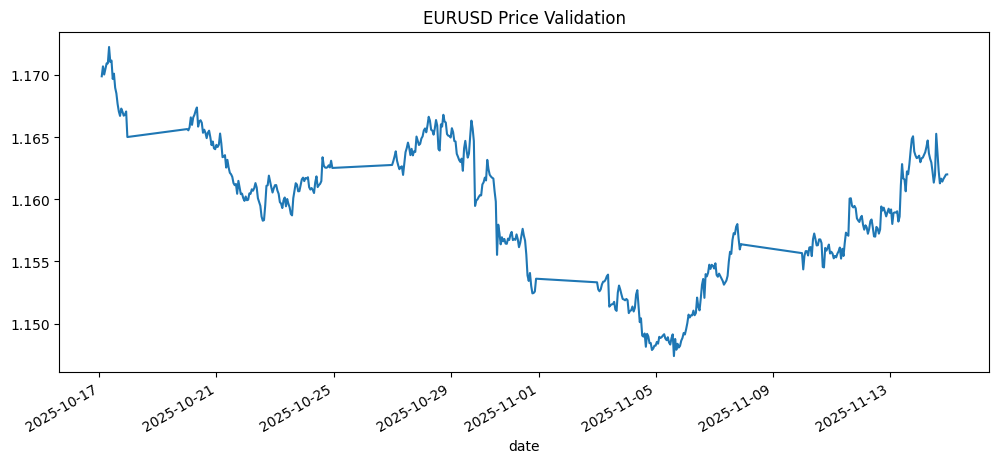

In [10]:
plt.figure(figsize=(12,5))
df["close"].iloc[-500:].plot()
plt.title("EURUSD Price Validation")

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/price_validation_v3.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1200x500 with 0 Axes>

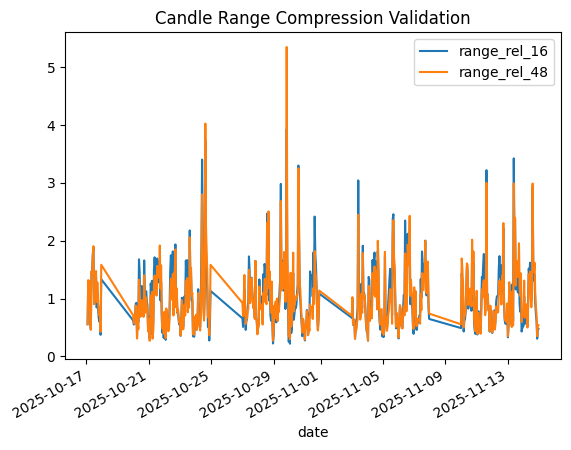

In [11]:
plt.figure(figsize=(12,5))
df[["range_rel_16","range_rel_48"]].iloc[-500:].plot()
plt.title("Candle Range Compression Validation")

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/range_validation_v3.png", dpi=300, bbox_inches="tight")
plt.show()